# 07 — Biodiesel model inference from noisy data (Sec. III A)

Reproduction of the ChemKAN paper's biodiesel results, in paper order:
**Fig. 3 → Fig. 4 → Figs. 5 and 6.**

Every section opens with a **Reproduction status** block stating which paper result it
targets, what is reproduced, and what is not. Nothing is presented as a completed paper
figure unless it is one.

Biodiesel is the isothermal case: the **kinetic core only**, no thermodynamic
superstructure, MSE loss with no PINN term.

In [1]:
%matplotlib inline

In [2]:
from pathlib import Path
import sys, csv
import numpy as np
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "chemkan" / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "chemkan" / "src"))
sys.path.insert(0, str(ROOT / "chemkan" / "scripts"))

from chemkan.normalization import MinMaxNormalizer
from chemkan.losses import trajectory_mse
from evaluate_biodiesel import (build_kinetic_core, solver_from_ckpt,
                                integrate_biodiesel)
from _data import load_biodiesel, load_input_scaling

RUN_DIR   = ROOT / "results/reproduction/chemkan/biodiesel/main/direct_autograd_seed0"
FIG_DIR   = ROOT / "results/reproduction/figures/biodiesel"
TABLE_DIR = ROOT / "results/reproduction/tables"
SAVE_FIGURES = True
for d in (FIG_DIR, TABLE_DIR):
    d.mkdir(parents=True, exist_ok=True)

npz = np.load(ROOT / "chemkan/data/generated/biodiesel.npz", allow_pickle=True)
species = [str(s) for s in npz["species"]]
t = npz["t"]

ckpt = torch.load(RUN_DIR / "checkpoint_final.pt", map_location="cpu", weights_only=False)
core = build_kinetic_core(ckpt, len(species), "cpu")
solver = solver_from_ckpt(ckpt)
input_norm = load_input_scaling(ckpt, "cpu")
n_params = sum(p.numel() for p in core.parameters() if p.requires_grad)

print("run_id      :", ckpt.get("run_id"))
print("parameters  :", n_params, "(paper: 156)")
print("architecture:", ckpt["architecture"])
print("species     :", species)
print("time grid   : %d points, %.4f to %.4f s, dt = %.5f s"
      % (len(t), t[0], t[-1], t[1] - t[0]))

run_id      : chemkan/biodiesel/main/direct_autograd_seed0
parameters  : 156 (paper: 156)
architecture: {'hidden_dim': 4, 'num_basis': 3, 'n_mu': 2, 'use_base_act': False}
species     : ['TG', 'ROH', 'DG', 'MG', 'GL', 'RCO2R']
time grid   : 30 points, 0.0000 to 30.0000 s, dt = 1.03448 s


## Model configuration vs the paper

| item | paper | this run | status |
|---|---|---|---|
| structure | kinetic core only (isothermal) | same | paper-stated |
| inputs | 6 species + T = 7 | 7 | paper-stated |
| hidden nodes | 4 | 4 | paper-stated |
| n_mu | 2 | 2 | paper-stated |
| grid points N | 3 ("three-point grids") | 3 | paper-stated |
| base activation | Eq. 11 defines a Swish coefficient | OFF | **inferred** |
| parameters | 156 | 156 | matches |
| loss | MSE only | MSE only | paper-stated |
| epochs | 10,000 | see config | paper-stated |
| sensitivity | forward sensitivity (FSA) | direct autograd | **deviation** |

Base-OFF is inferred, but the inference is sound here: parameter counts alone cannot
distinguish base-ON at N-1 from base-OFF at N, and the tie is broken by the paper's
explicit three-point grids - at N = 3, base-ON would give 208 rather than 156.

`P = 13 h N`, so at N = 3 the family is `P = 39h`: h=2 -> 78 and h=4 -> 156, both named
in the paper.

## Time-grid status — RESOLVED: keep `linspace(0, 30, 30)`

The paper states three things that cannot all hold at once for an endpoint-inclusive
30-point grid: a 30-second window, 30 sampled points, and a sparse interval of 1 s.
Sec. 3.1.1 words it as *"sampled from the ground truth at a sparse time interval of 1 s,
leading to 30 total data points for each individual species."*

**Decision (supervisor-reviewed): the dataset keeps `np.linspace(0, 30, 30)`**, giving
dt = 30/29 = 1.03448 s with the first sample at t = 0 and every point supervised. This
honours "30 sampled data points" and reads "1 s" as the paper's rounded description of
the ≈1.0345 s spacing. The data-generation setup is **fixed for this reproduction**.

**Alternative interpretation (not adopted).** A high-resolution measurement of the
data markers in **Fig. 3** gives 30 markers at dt = 1.003 s, the first roughly one full
spacing after t = 0 and the last at t = 30 — consistent with integrating on
`0, 1, …, 30` and supervising only `t = 1…30`, with `t = 0` as the known initial
condition. This reading remains defensible on the marker evidence. It was **not adopted**
because it is itself a reconstruction rather than a paper-explicit indexing convention,
and because switching would invalidate and require retraining every biodiesel model
here (Figs. 3–6).

See `chemkan/src/chemkan/ASSUMPTIONS.md` §4b. Results in this notebook are **no longer
provisional on this point**.

In [3]:
BIODIESEL_TIME_GRID_STATUS = "RESOLVED - keep linspace(0, 30, 30)"
print("status           :", BIODIESEL_TIME_GRID_STATUS)
print("time grid in use :", f"linspace(0, 30, {len(t)})  dt = {t[1]-t[0]:.5f} s")
print("alt. not adopted :", "t = 1..30 at dt = 1 s (Fig. 3 markers measure dt = 1.003 s)")

# The results below were computed on the 30-point grid. Fail loudly rather than
# silently reporting numbers from a different archive than the one that was trained on.
assert len(t) == 30, (
    f"biodiesel.npz has {len(t)} time points, expected 30 (linspace(0, 30, 30)). "
    "Every checkpoint in this notebook was trained on the 30-point grid; regenerate "
    "with the committed generator defaults or re-run the models.")

status           : RESOLVED - keep linspace(0, 30, 30)
time grid in use : linspace(0, 30, 30)  dt = 1.03448 s
alt. not adopted : t = 1..30 at dt = 1 s (Fig. 3 markers measure dt = 1.003 s)


---
## III A.1 — Model performance / Figure 3

**Reproduction status**

- **Paper target:** Sec. III A.1, Figure 3
- **Paper claim:** with clean data the ChemKAN learns the underlying model and predicts
  smoothly *between* the sparse observation times; it stays robust as noise increases to
  15%.
- **Paper configuration:** 156 parameters, 4 hidden nodes, n_mu = 2, three-point grids,
  10,000 epochs; four columns at 0%, 5%, 10%, 15% noise.
- **Our artifact:** the single clean (0% noise) checkpoint above.
- **What is reproduced:** the clean-data / 0%-noise component - the leftmost column of
  Fig. 3, and the smooth-interpolation claim, evaluated on a dense time grid.
- **What is NOT reproduced:** the 5%, 10% and 15% noise models; the exact paper plotting
  condition; the paper's noise realization.
- **Reproduction differences:** direct autograd rather than FSA; base-OFF inferred. The
  time grid is RESOLVED (`linspace(0, 30, 30)`) - see the status section above.

In [4]:
res = {}
for split in ("train", "test"):
    data = load_biodiesel(split=split)
    m = data["species_TBm"].shape[-1]
    norm = MinMaxNormalizer(data["u_min"][:m], data["u_max"][:m])
    pred = integrate_biodiesel(core, input_norm, solver,
                               data["species_TBm"][0], data["T_const"], data["t"])
    mse = trajectory_mse(norm.normalize(pred),
                         norm.normalize(data["species_TBm"])).item()
    res[split] = dict(data=data, pred=pred.detach(), mse=mse)
    print(f"{split:5s}: normalized trajectory MSE = {mse:.4f}"
          f"   ({data['species_TBm'].shape[1]} trajectories)")

print()
print("Metric convention (Eq. 18): mean over the 6 species at each time,")
print(f"summed over the {len(t)} observation times, then mean over trajectories.")
print(f"Per observation time that is ~{res['test']['mse']/len(t):.2e} for the test split.")

train: normalized trajectory MSE = 0.0620   (20 trajectories)
test : normalized trajectory MSE = 0.0814   (10 trajectories)

Metric convention (Eq. 18): mean over the 6 species at each time,
summed over the 30 observation times, then mean over trajectories.
Per observation time that is ~2.71e-03 for the test split.


### Figure 3 — clean-data column, dense evaluation

The paper's point is that the model is smooth *between* the 30 sparse observations. That
can only be checked by evaluating the model at times it never saw, so the curves below
come from a dense grid, not from the 30 training points.

The plotted case is an unseen **test** trajectory. It is **not** the paper's Fig. 3
condition ([TG] = 1.94, [ROH] = 1.43, T = 334.8 K), which is not in the canonical random
test split - reproducing that exact column needs a dedicated case artifact.

saved /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien/results/reproduction/figures/biodiesel/fig03_biodiesel_clean_column.pdf


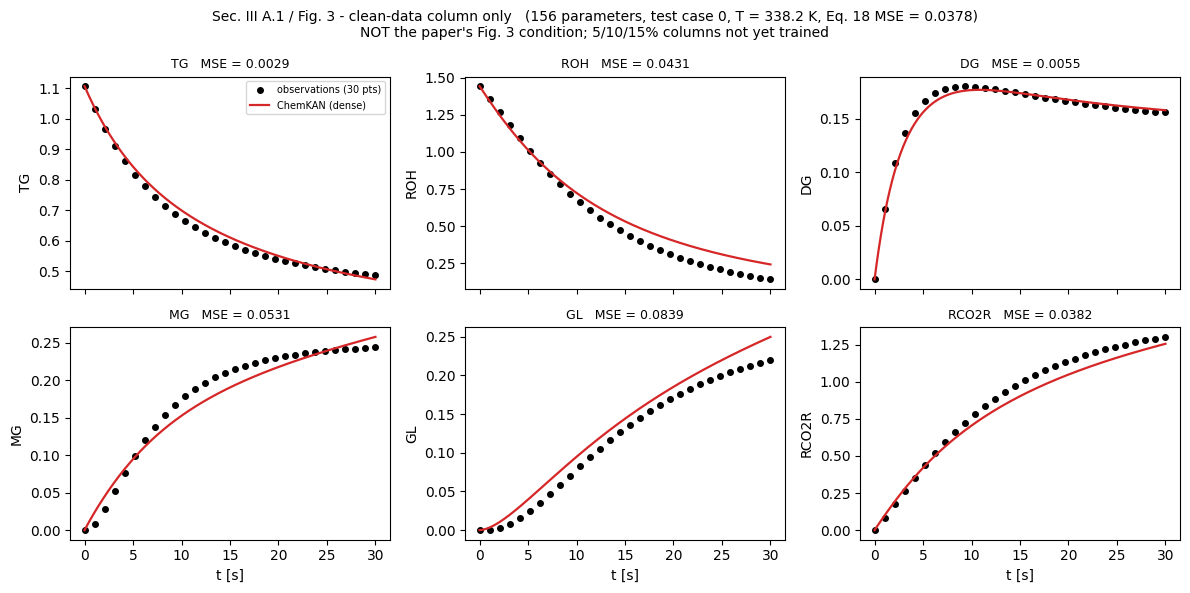

test case 0: Eq. 18 MSE = 0.0378   (panel MSE is scored on the 30 observation times, not the dense grid)


In [5]:
CASE = 0
t_dense = np.linspace(float(t[0]), float(t[-1]), 400)

d = res["test"]["data"]
m = len(species)
Y0 = d["species_TBm"][0][CASE:CASE+1]
Tc = d["T_const"][CASE:CASE+1]
dense = integrate_biodiesel(core, input_norm, solver, Y0, Tc,
                            torch.as_tensor(t_dense, dtype=torch.get_default_dtype()))
dense = dense[:, 0].detach().numpy()
truth = d["species_TBm"][:, CASE].numpy()

# Per-species Eq. 18 normalized MSE for THIS case, scored on the 30-pt observation grid
# (the dense curve is for display only -- it has no reference to score against).
nrm = MinMaxNormalizer(d["u_min"][:m], d["u_max"][:m])              # train-only stats
pred_obs = res["test"]["pred"][:, CASE]                             # (T, m) model at obs times
sqn = (nrm.normalize(pred_obs) - nrm.normalize(d["species_TBm"][:, CASE])) ** 2
per_sp = sqn.sum(0).detach().numpy()                               # (m,) Eq. 18 per species
case_mse = float(per_sp.mean())                                    # case-level Eq. 18 MSE

fig, ax = plt.subplots(2, 3, figsize=(12, 6), sharex=True)
for k, sp in enumerate(species):
    a = ax[k // 3, k % 3]
    a.plot(t, truth[:, k], "o", ms=4, color="k", label="observations (30 pts)")
    a.plot(t_dense, dense[:, k], "-", lw=1.6, color="tab:red", label="ChemKAN (dense)")
    a.set_ylabel(sp)
    a.set_title(f"{sp}   MSE = {per_sp[k]:.4f}", fontsize=9)
    if k >= 3:
        a.set_xlabel("t [s]")
    if k == 0:
        a.legend(fontsize=7)

fig.suptitle(f"Sec. III A.1 / Fig. 3 - clean-data column only   "
             f"({n_params} parameters, test case {CASE}, T = {float(Tc[0]):.1f} K, "
             f"Eq. 18 MSE = {case_mse:.4f})\n"
             f"NOT the paper's Fig. 3 condition; 5/10/15% columns not yet trained",
             fontsize=10)
fig.tight_layout()
if SAVE_FIGURES:
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"fig03_biodiesel_clean_column.{ext}",
                    dpi=300, bbox_inches="tight")
    print("saved", FIG_DIR / "fig03_biodiesel_clean_column.pdf")
plt.show()

print(f"test case {CASE}: Eq. 18 MSE = {case_mse:.4f}   (panel MSE is scored on the 30 "
      f"observation times, not the dense grid)")


### Per-species fit across all unseen test trajectories

The Fig. 3 panel shows one test case. This shows all ten at once, species by species:
dots are the ground truth at the 30 observation times, curves are the ChemKAN evaluated
on a dense grid. Each colour is one test trajectory (a different initial condition and
temperature), so a species the model systematically misses shows up immediately.

saved /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien/results/reproduction/figures/biodiesel/biodiesel_test_per_species.png


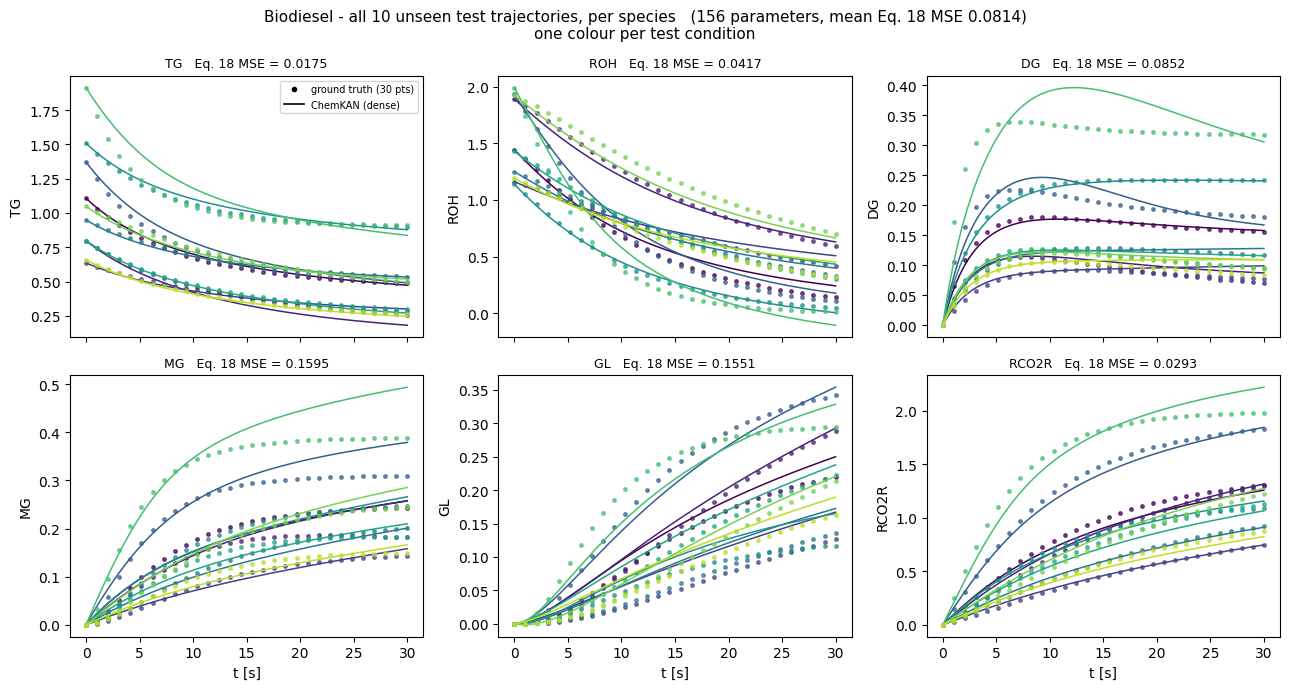


per-species Eq. 18 MSE (summed over 30 times, mean over 10 trajectories):
   MG       0.1595
   GL       0.1551
   DG       0.0852
   ROH      0.0417
   RCO2R    0.0293
   TG       0.0175


In [6]:
d = res["test"]["data"]
truth = d["species_TBm"].numpy()                      # (T, B, m)
B = truth.shape[1]

# dense model curves for all 10 test trajectories at once
dense_all = integrate_biodiesel(
    core, input_norm, solver, d["species_TBm"][0], d["T_const"],
    torch.as_tensor(t_dense, dtype=torch.get_default_dtype())).detach().numpy()

# per-species Eq. 18 error, on the observation grid
nrm = MinMaxNormalizer(d["u_min"][:len(species)], d["u_max"][:len(species)])
sq = (nrm.normalize(res["test"]["pred"]) - nrm.normalize(d["species_TBm"]))**2
per_species = sq.sum(0).mean(0).detach().numpy()      # sum over time, mean over traj

colors = plt.cm.viridis(np.linspace(0, .9, B))
fig, ax = plt.subplots(2, 3, figsize=(13, 7), sharex=True)
for k, sp in enumerate(species):
    a = ax[k // 3, k % 3]
    for b in range(B):
        a.plot(t, truth[:, b, k], "o", ms=2.5, color=colors[b], alpha=.7)
        a.plot(t_dense, dense_all[:, b, k], "-", lw=1.1, color=colors[b])
    a.set_ylabel(sp)
    a.set_title(f"{sp}   Eq. 18 MSE = {per_species[k]:.4f}", fontsize=9)
    if k >= 3:
        a.set_xlabel("t [s]")

ax[0, 0].plot([], [], "ko", ms=3, label="ground truth (30 pts)")
ax[0, 0].plot([], [], "k-", lw=1.2, label="ChemKAN (dense)")
ax[0, 0].legend(fontsize=7, loc="upper right")

fig.suptitle(f"Biodiesel - all {B} unseen test trajectories, per species   "
             f"({n_params} parameters, mean Eq. 18 MSE {res['test']['mse']:.4f})\n"
             f"one colour per test condition", fontsize=11)
fig.tight_layout()
if SAVE_FIGURES:
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"biodiesel_test_per_species.{ext}", dpi=300,
                    bbox_inches="tight")
    print("saved", FIG_DIR / "biodiesel_test_per_species.png")
plt.show()

print("\nper-species Eq. 18 MSE (summed over 30 times, mean over 10 trajectories):")
for sp, v in sorted(zip(species, per_species), key=lambda x: -x[1]):
    print(f"   {sp:8s} {v:.4f}")

### Per-species error summary (train vs test)

A compact quantitative companion to the trajectory panels above: the Eq. 18 normalized MSE
for **each species**, on the training and the unseen-test split, side by side. Both splits
use the **train-only** min-max statistics (Eq. 18). Because the total metric averages the
per-species values over species, the **mean bar height equals the reported split MSE** — a
built-in consistency check. Species with a systematically taller bar are the ones the
156-parameter core reconstructs least well. The values are also written to
`tables/biodiesel_per_species_mse.csv`.

saved /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien/results/reproduction/figures/biodiesel/biodiesel_per_species_mse.png


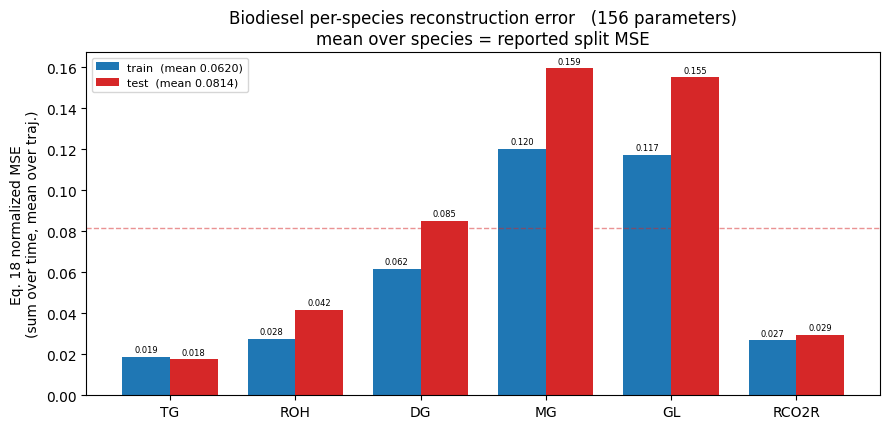

saved /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien/results/reproduction/tables/biodiesel_per_species_mse.csv
consistency: train mean 0.0620 vs reported 0.0620 | test mean 0.0814 vs reported 0.0814


In [7]:
# Per-species Eq. 18 normalized MSE (sum over time, mean over trajectories), train vs test.
def per_species_mse(split):
    d = res[split]["data"]
    m = len(species)
    nrm = MinMaxNormalizer(d["u_min"][:m], d["u_max"][:m])          # train-only stats (Eq. 18)
    sq = (nrm.normalize(res[split]["pred"]) - nrm.normalize(d["species_TBm"])) ** 2
    return sq.sum(0).mean(0).detach().numpy()                       # (m,)

ps_train, ps_test = per_species_mse("train"), per_species_mse("test")

x, w = np.arange(len(species)), 0.38
fig, ax = plt.subplots(figsize=(9, 4.4))
b1 = ax.bar(x - w / 2, ps_train, w, color="tab:blue",
            label=f"train  (mean {ps_train.mean():.4f})")
b2 = ax.bar(x + w / 2, ps_test, w, color="tab:red",
            label=f"test  (mean {ps_test.mean():.4f})")
ax.axhline(ps_test.mean(), color="tab:red", ls="--", lw=1, alpha=.5)
ax.set_xticks(x); ax.set_xticklabels(species)
ax.set_ylabel("Eq. 18 normalized MSE\n(sum over time, mean over traj.)")
ax.set_title(f"Biodiesel per-species reconstruction error   ({n_params} parameters)\n"
             "mean over species = reported split MSE")
ax.legend(fontsize=8)
for bars in (b1, b2):
    ax.bar_label(bars, fmt="%.3f", fontsize=6, padding=2)
fig.tight_layout()
if SAVE_FIGURES:
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"biodiesel_per_species_mse.{ext}", dpi=300, bbox_inches="tight")
    print("saved", FIG_DIR / "biodiesel_per_species_mse.png")
plt.show()

# machine-readable table
tbl = TABLE_DIR / "biodiesel_per_species_mse.csv"
with tbl.open("w", newline="") as f:
    wr = csv.writer(f); wr.writerow(["species", "train_mse", "test_mse"])
    for sp, a, b in zip(species, ps_train, ps_test):
        wr.writerow([sp, f"{a:.6f}", f"{b:.6f}"])
    wr.writerow(["MEAN(=split MSE)", f"{ps_train.mean():.6f}", f"{ps_test.mean():.6f}"])
print("saved", tbl)

# consistency check: mean over species must equal the reported split MSE
print(f"consistency: train mean {ps_train.mean():.4f} vs reported {res['train']['mse']:.4f} | "
      f"test mean {ps_test.mean():.4f} vs reported {res['test']['mse']:.4f}")


### Training history

10000 epochs | first 1.2766e+03 | final 9.1260e-02   (column 'total_loss')


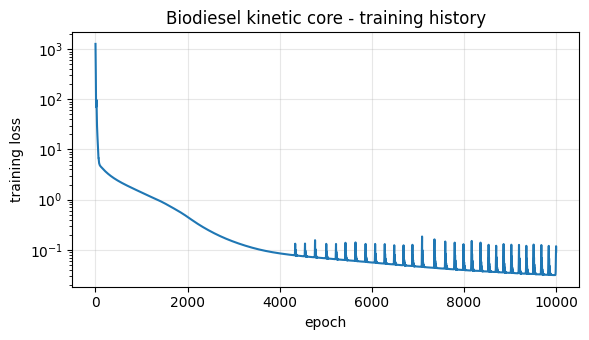

In [8]:
h = RUN_DIR / "history.csv"
if not h.exists():
    h = next(RUN_DIR.glob("history*.csv"), None)
if h is None:
    print("no history file found in", RUN_DIR)
else:
    rows = list(csv.DictReader(h.open()))
    key = next((k for k in rows[0] if "total" in k.lower() and "loss" in k.lower()),
               next(k for k in rows[0] if "loss" in k.lower()))
    loss = [float(r[key]) for r in rows]
    print(f"{len(rows)} epochs | first {loss[0]:.4e} | final {loss[-1]:.4e}"
          f"   (column '{key}')")
    fig, a = plt.subplots(figsize=(6, 3.5))
    a.semilogy(loss)
    a.set_xlabel("epoch"); a.set_ylabel("training loss"); a.grid(alpha=.3)
    a.set_title("Biodiesel kinetic core - training history")
    plt.tight_layout(); plt.show()

---
## III A.2 — Neural scaling / Figure 4

**Reproduction status**

- **Paper target:** Sec. III A.2, Figure 4
- **Paper claim:** ChemKAN scales at order -1.0 (training) and -0.6 (testing); DeepONet
  at -4.0 and -1.4, but overfits past ~308 parameters while ChemKAN plateaus.
- **Required:** a ChemKAN sweep at 5,000 epochs plus a DeepONet sweep at 50,000 epochs,
  on clean data. These are separate runs from the 10k models used in Figs. 3/5/6.
- **Status:** NOT STARTED. The DeepONet baseline is not yet implemented, and no scaling
  runs exist.

Note for later: the paper's DeepONet is reported as 308 parameters, but the architecture
as literally described (branch [7,8,8,8] = 208, trunk [1,7,8] = 78, MLP_opt Linear(8,6)
= 54) gives **340**. 340 is authoritative for this reproduction.

---
## III A.3 — Noisy comparison / Figures 5 and 6

**Reproduction status**

- **Paper target:** Sec. III A.3, Figures 5 and 6
- **Paper claim:** across 0-15% noise the ChemKAN keeps a lower noise-free testing error
  than a comparable DeepONet, which overfits the noise; at 15% the DeepONet's noise-free
  testing loss is about 4.4x the ChemKAN's.
- **Required:** 7 ChemKAN and 7 DeepONet runs at 10,000 epochs (0/1/2/5/7/10/15%), plus
  per-epoch noise-free testing history for Fig. 5B.
- **Status:** NOT STARTED beyond the 0% ChemKAN model above. The stored noise arrays
  exist in the archive and are listed below.

### Metric convention diagnostic — literal Eq. 18 vs conventional time-averaged MSE

Eq. 18's MSE term reads `(1/n*) Σ_j Σ_k (û_k^pred(t_j) − û_k^obs(t_j))²` — a mean over the
`n*` normalized states but a **sum** over the `N_t` observation times. Most reported MSEs in
the ML literature average over time as well. The two differ by exactly the factor `N_t = 30`,
so which one the paper's figures plot changes any comparison by more than an order of
magnitude.

**This is a reporting diagnostic only. It does not change training** — the loss actually
optimized is, and remains, the literal Eq. 18 form (`chemkan.losses.trajectory_mse`).

In [9]:
# Same predictions, two reductions. Training is unaffected -- this only reports.
Nt = len(t)
print(f"N_t = {Nt} observation times\n")
for split in ("train", "test"):
    eq18 = res[split]["mse"]                      # mean over states, SUM over time
    tavg = eq18 / Nt                              # ... and mean over time instead
    print(f"{split + ':':6s} Eq18 = {eq18:.7f}")
    print(f"       time-averaged MSE = {tavg:.4e}")
    print(f"       ratio = {eq18 / tavg:.3f}\n")
print("The two differ by exactly N_t = 30. The OPTIMIZED loss is the literal Eq. 18 form;")
print("the time-averaged column exists only to make paper comparisons explicit about which")
print("reduction is being quoted. Nothing here changes training.")

N_t = 30 observation times

train: Eq18 = 0.0620165
       time-averaged MSE = 2.0672e-03
       ratio = 30.000

test:  Eq18 = 0.0814005
       time-averaged MSE = 2.7134e-03
       ratio = 30.000

The two differ by exactly N_t = 30. The OPTIMIZED loss is the literal Eq. 18 form;
the time-averaged column exists only to make paper comparisons explicit about which
reduction is being quoted. Nothing here changes training.


---
## Section III A — completion status

| result | status |
|---|---|
| Fig. 3 | **complete** - all four noise columns on the paper's explicit unseen condition (see the section below) |
| Fig. 4 | **complete, slopes not reproduced** - widths from digitizing the paper figure; ChemKAN -0.41/-0.38 vs -1.0/-0.6 and DeepONet -0.95/-0.62 vs -4.0/-1.4, all with R^2 <= 0.46 |
| Fig. 5A | **complete** - 8 ChemKAN + 8 DeepONet conditions at 10k; B0 reused for ChemKAN 0% |
| Fig. 5B | **complete** - per-epoch noise-free test history logged in every run; the 0% panel comes from the clean replay, which reproduces B0 bitwise |
| Fig. 6 | **complete** - reuses the Fig. 5 15% ChemKAN and DeepONet checkpoints, no new training |

### What this run establishes

The 156-parameter kinetic core trains and reconstructs the biodiesel trajectories from
sparse data, with the paper's exact architecture: 4 hidden nodes, n_mu = 2, three-point
grids, 156 parameters, MSE-only loss. That is the model underlying all of Sec. III A.

### Comparability to the paper's reported MSE

The paper's Eq. 18 MSE term is `(1/n*) Σ_j Σ_k (û_k^pred(t_j) − û_k^obs(t_j))²` — mean
over the `n*` normalized states, **summed** over the `N_t` observation times. That is
**exactly** this repository's `chemkan.losses.trajectory_mse` convention, plus a mean
over trajectories (the paper reports "average" results). The reductions are compatible.

What the paper actually reports as numbers, however, is almost entirely **relative**:

| paper quantity | value | comparable to our metric? |
|---|---|---|
| ChemKAN training/testing error magnitude, noise-free, 72 params (Sec. 3.1.2) | "already around 10⁻⁴" | **approximate only** — prose, not a table; 72 params, not our 156; read against a log-axis figure; **and the paper does not state which time reduction its figures use** |
| MSE increase, 0% → 1% noise | 3.78 × 10⁻⁵ | form is comparable; **needs the noise sweep — not run** |
| MSE increase, 0% → 5% noise | 9.64 × 10⁻⁴ | same — **not run** |
| ChemKAN noise-free testing increase, 0% → 15% | ≈ 2× | **not run** (also Eq. 22, a *different* metric from Eq. 18) |
| DeepONet noise-free testing increase, 0% → 15% | ≈ 5× | **not run**; also needs the DeepONet |
| DeepONet / ChemKAN noise-free testing ratio at 15% | 4.4× | **not run**; needs both sweeps |
| Fig. 4 fitted scaling slopes Δ | 1.0 train, 0.6 test | **not run**; needs the scaling sweep |

**Our only currently comparable number is the order-of-magnitude anchor, and the
comparison is approximate**, because it depends on a reduction the paper does not state.
This run gives:

| reduction | train | test |
|---|---|---|
| literal Eq. 18 (mean over states, **sum** over 30 times) | 0.062 | 0.081 |
| conventional time-averaged MSE (Eq. 18 ÷ `N_t`) | 2.07 × 10⁻³ | 2.71 × 10⁻³ |

Against the paper's "around 10⁻⁴", the literal Eq. 18 value sits ~10²–10³ × higher and the
time-averaged value ~10–30 × higher. **Which of these is the like-for-like comparison is
not determinable from the paper**, which states the Eq. 18 formula but does not say which
reduction its Fig. 4 axis plots. The remaining difference is **not explained** — candidate
causes are the sensitivity backend (direct autograd vs FSA), the late-epoch oscillation
documented in the training-history section, the different parameter count (72 vs 156), and
unresolved data-generation details.

**No claim of a quantitative Fig. 3 or Fig. 4 match should be made on this evidence, and
no claim of a specific performance ratio either.** The noise sweep below now supplies the
Fig. 5 rows of this table; the Fig. 4 slope rows follow when the width sweep finishes.

### Open items

- **Time grid RESOLVED** - `linspace(0, 30, 30)` retained; see the status section above
  and ASSUMPTIONS.md §4b.
- **Absolute MSE gap to the paper** (above) is unexplained and is the main open
  quantitative discrepancy for biodiesel; its size depends on a time reduction the paper
  does not state, so it is reported under both conventions rather than as one ratio.
- **DeepONet baseline** implemented (`deeponet/biodiesel_deeponet.py` + trainer and
  evaluator) and run at all eight noise levels. Literal paper-described architecture at
  w=8: **340** measured parameters against the **308** reported - documented and not
  engineered away. Its input/output scaling is a labelled REPRODUCTION CHOICE (min-max
  branch input, `tau = t/t_end`, normalized-species output), since raw inputs put the
  initial loss around 5e7 purely from conditioning.
- **Base-activation path** inferred; the matched-parameter sensitivity run
  (h=4, N=2, base-ON, also 156 parameters) is **done in the section below** - base-ON
  overfits (better train, worse test), which supports the base-OFF reading.
- **Sensitivity backend** is direct autograd, not the paper's FSA.

---
## Base-activation sensitivity — matched 156-parameter check

The configuration table lists **base activation OFF** as *inferred*. A parameter count of
156 is consistent with **base-OFF at N = 3** (the paper's explicit three-point grid) but
**also** with **base-ON at N = 2**, block for block — parameter count alone cannot break
the tie. This section trains the matched alternative (`--use-base-act`, `h = 4, N = 2`, also
**156 parameters**, in `sensitivity/base_on_matched_seed0`) and compares it against the
base-OFF main run to see whether the choice materially changes the reconstruction.

Same data, same seed, same optimiser, same 156 parameters; only the base-activation path
(and the compensating grid size N) differ. This closes the "matched-parameter sensitivity
run" listed as an open item above.

In [10]:
# Load the matched base-ON run and evaluate both models on train + test.
RUN_DIR_ON = ROOT / "results/reproduction/chemkan/biodiesel/sensitivity/base_on_matched_seed0"
ckpt_on = torch.load(RUN_DIR_ON / "checkpoint_final.pt", map_location="cpu", weights_only=False)
core_on = build_kinetic_core(ckpt_on, len(species), "cpu")
input_norm_on = load_input_scaling(ckpt_on, "cpu")
solver_on = solver_from_ckpt(ckpt_on)
n_params_on = sum(p.numel() for p in core_on.parameters() if p.requires_grad)
print("base-OFF arch :", ckpt["architecture"], "->", n_params, "params")
print("base-ON  arch :", ckpt_on["architecture"], "->", n_params_on, "params")

def _eval_split(core_, inorm_, solver_, split):
    """(total Eq. 18 MSE, per-species Eq. 18 MSE) for a model on a split (train-only stats)."""
    d = load_biodiesel(split=split); mm = len(species)
    nrm = MinMaxNormalizer(d["u_min"][:mm], d["u_max"][:mm])
    pred = integrate_biodiesel(core_, inorm_, solver_,
                               d["species_TBm"][0], d["T_const"], d["t"]).detach()
    total = trajectory_mse(nrm.normalize(pred), nrm.normalize(d["species_TBm"])).item()
    per = ((nrm.normalize(pred) - nrm.normalize(d["species_TBm"])) ** 2).sum(0).mean(0).detach().numpy()
    return total, per

cmp = {"base-OFF (main, N=3)": {}, "base-ON (matched, N=2)": {}}
for split in ("train", "test"):
    cmp["base-OFF (main, N=3)"][split] = _eval_split(core, input_norm, solver, split)
    cmp["base-ON (matched, N=2)"][split] = _eval_split(core_on, input_norm_on, solver_on, split)

for name, r in cmp.items():
    print(f"{name:24s} train {r['train'][0]:.4f} | test {r['test'][0]:.4f}")
gap_off = cmp["base-OFF (main, N=3)"]["test"][0] - cmp["base-OFF (main, N=3)"]["train"][0]
gap_on = cmp["base-ON (matched, N=2)"]["test"][0] - cmp["base-ON (matched, N=2)"]["train"][0]
print(f"\ngeneralization gap (test - train): base-OFF {gap_off:+.4f} | base-ON {gap_on:+.4f}")


base-OFF arch : {'hidden_dim': 4, 'num_basis': 3, 'n_mu': 2, 'use_base_act': False} -> 156 params
base-ON  arch : {'hidden_dim': 4, 'num_basis': 2, 'n_mu': 2, 'use_base_act': True} -> 156 params
base-OFF (main, N=3)     train 0.0620 | test 0.0814
base-ON (matched, N=2)   train 0.0438 | test 0.1212

generalization gap (test - train): base-OFF +0.0194 | base-ON +0.0774


saved /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien/results/reproduction/figures/biodiesel/biodiesel_base_on_vs_off.png


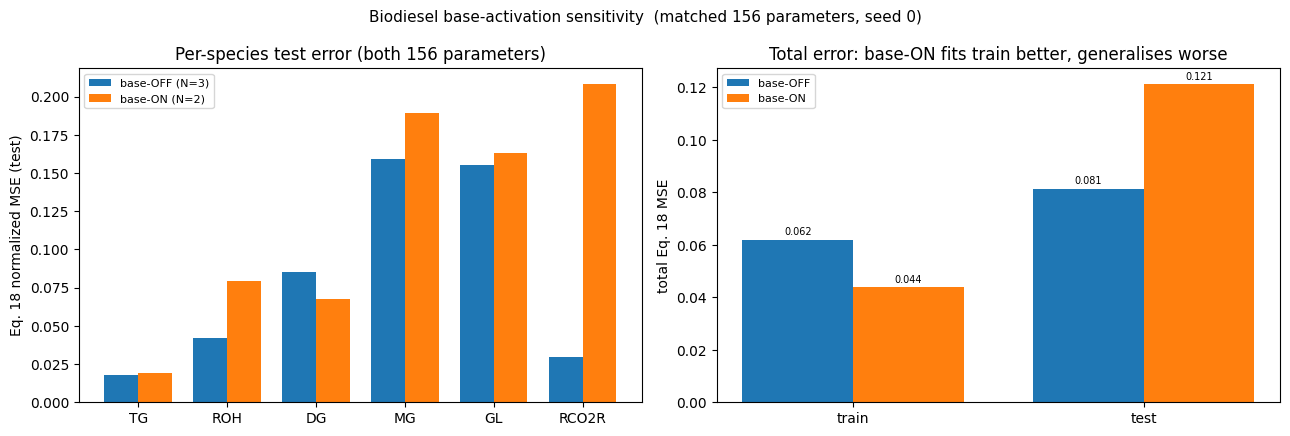

saved /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien/results/reproduction/tables/biodiesel_base_on_vs_off.csv


In [11]:
# Comparison plot + table: per-species test error and total train/test error, OFF vs ON.
OFF, ON = "base-OFF (main, N=3)", "base-ON (matched, N=2)"
off_test, on_test = cmp[OFF]["test"][1], cmp[ON]["test"][1]
x, w = np.arange(len(species)), 0.38

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
ax[0].bar(x - w / 2, off_test, w, color="tab:blue", label="base-OFF (N=3)")
ax[0].bar(x + w / 2, on_test, w, color="tab:orange", label="base-ON (N=2)")
ax[0].set_xticks(x); ax[0].set_xticklabels(species)
ax[0].set_ylabel("Eq. 18 normalized MSE (test)")
ax[0].set_title("Per-species test error (both 156 parameters)")
ax[0].legend(fontsize=8)

splits = ["train", "test"]; xt = np.arange(2)
off_tot = [cmp[OFF][s][0] for s in splits]; on_tot = [cmp[ON][s][0] for s in splits]
bo = ax[1].bar(xt - w / 2, off_tot, w, color="tab:blue", label="base-OFF")
bn = ax[1].bar(xt + w / 2, on_tot, w, color="tab:orange", label="base-ON")
ax[1].set_xticks(xt); ax[1].set_xticklabels(splits)
ax[1].set_ylabel("total Eq. 18 MSE")
ax[1].set_title("Total error: base-ON fits train better, generalises worse")
ax[1].legend(fontsize=8)
for bars in (bo, bn):
    ax[1].bar_label(bars, fmt="%.3f", fontsize=7, padding=2)

fig.suptitle("Biodiesel base-activation sensitivity  (matched 156 parameters, seed 0)", fontsize=11)
fig.tight_layout()
if SAVE_FIGURES:
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"biodiesel_base_on_vs_off.{ext}", dpi=300, bbox_inches="tight")
    print("saved", FIG_DIR / "biodiesel_base_on_vs_off.png")
plt.show()

# machine-readable table
p = TABLE_DIR / "biodiesel_base_on_vs_off.csv"
with p.open("w", newline="") as f:
    wr = csv.writer(f)
    wr.writerow(["metric", "base_off", "base_on"])
    wr.writerow(["parameters", n_params, n_params_on])
    wr.writerow(["train_total_mse", f"{cmp[OFF]['train'][0]:.6f}", f"{cmp[ON]['train'][0]:.6f}"])
    wr.writerow(["test_total_mse", f"{cmp[OFF]['test'][0]:.6f}", f"{cmp[ON]['test'][0]:.6f}"])
    for k, sp in enumerate(species):
        wr.writerow([f"test_{sp}_mse", f"{off_test[k]:.6f}", f"{on_test[k]:.6f}"])
print("saved", p)


### What the base-ON comparison shows

| | base-OFF (main, N=3) | base-ON (matched, N=2) |
|---|---|---|
| parameters | 156 | 156 |
| train MSE | 0.062 | **0.044** |
| test MSE | **0.081** | 0.121 |
| gen. gap (test − train) | +0.019 | +0.077 |

At matched parameter count, **base-ON fits the training data better** (0.044 < 0.062) but
**generalises worse** (test 0.121 > 0.081), with a ~4× larger train→test gap — a classic
**overfitting** signature, concentrated on RCO2R and ROH. The two 156-parameter readings
are therefore **not equivalent**: the extra base-activation flexibility is spent memorising
the training trajectories rather than the underlying model.

This **supports the base-OFF inference** on two independent grounds: (1) it is the reading
consistent with the paper's explicit three-point grids (base-ON at N = 3 would be 208, not
156), and (2) at matched parameter count it generalises better here. **Caveat:** single
seed — a firmer conclusion would average over several seeds.

---

## Figures 3, 5A, 5B and 6 — from the completed noise sweep

Sixteen runs at 10,000 epochs: seven noisy ChemKAN levels, eight DeepONet levels, and one
clean ChemKAN replay. `B0` is reused unchanged as the established 0 % ChemKAN result.

**The clean replay is a bitwise reproduction of `B0`** — identical weights and an identical
training loss at all 10,000 epochs — differing only by the two evaluation-only columns
(`test_mse_noisy`, `test_mse_clean`) that `B0`'s history lacks. Figure 5B's 0 % panel
therefore plots `B0`'s own trajectory rather than a substitute run, and no history is
spliced between runs.

All Fig.-5A numbers come from **final checkpoints**, never from the last history row: the
checkpoint is the state *after* the 10,000th update while the last history row is the state
*before* it, and the two differ measurably.

In [12]:
import csv, sys, numpy as np, torch
import matplotlib.pyplot as plt
sys.path.insert(0, str(ROOT / "deeponet"))

TAB = ROOT / "results/reproduction/tables"
CKB = ROOT / "results/reproduction/chemkan/biodiesel"
DON = ROOT / "results/reproduction/baselines/deeponet/biodiesel/noise"
FIGB = ROOT / "results/reproduction/figures/biodiesel"; FIGB.mkdir(parents=True, exist_ok=True)

def history(run_dir):
    r = list(csv.DictReader(open(run_dir / "history.csv")))
    return (np.array([float(x["epoch"]) for x in r]),
            np.array([float(x["total_loss"]) for x in r]),
            np.array([float(x["test_mse_clean"]) for x in r]))

def chemkan_run(pct):
    """B0 is the established 0 % result; the replay is Fig.-5B history only."""
    return CKB / "main/direct_autograd_seed0" if pct == 0 else CKB / f"noise/noise{pct:02d}_seed0"

metrics = [r for r in csv.DictReader(open(TAB / "biodiesel_fig5a_metrics.csv"))]
levels = sorted({int(r["noise_percent"]) for r in metrics if r["role"] == "plotted"})
print("noise levels:", levels)
print("runs:", len([r for r in metrics if r["role"] == "plotted"]), "plotted +",
      len([r for r in metrics if r["role"] != "plotted"]), "replay (not plotted in 5A)")

noise levels: [0, 1, 2, 3, 5, 7, 10, 15]
runs: 16 plotted + 1 replay (not plotted in 5A)


### Figure 3 — the paper's explicit unseen condition

`TG0 = 1.94`, `ROH0 = 1.43`, all other species zero, `T = 334.8 K` (PAPER EXPLICIT). This
state is not in the 10-case test split, so it is generated as a dedicated artifact with the
same ODE, solver settings and noise convention as the dataset; the canonical split is
untouched. Predictions are closed-loop integrations from the initial condition on a dense
601-point grid — no intermediate observations are used.

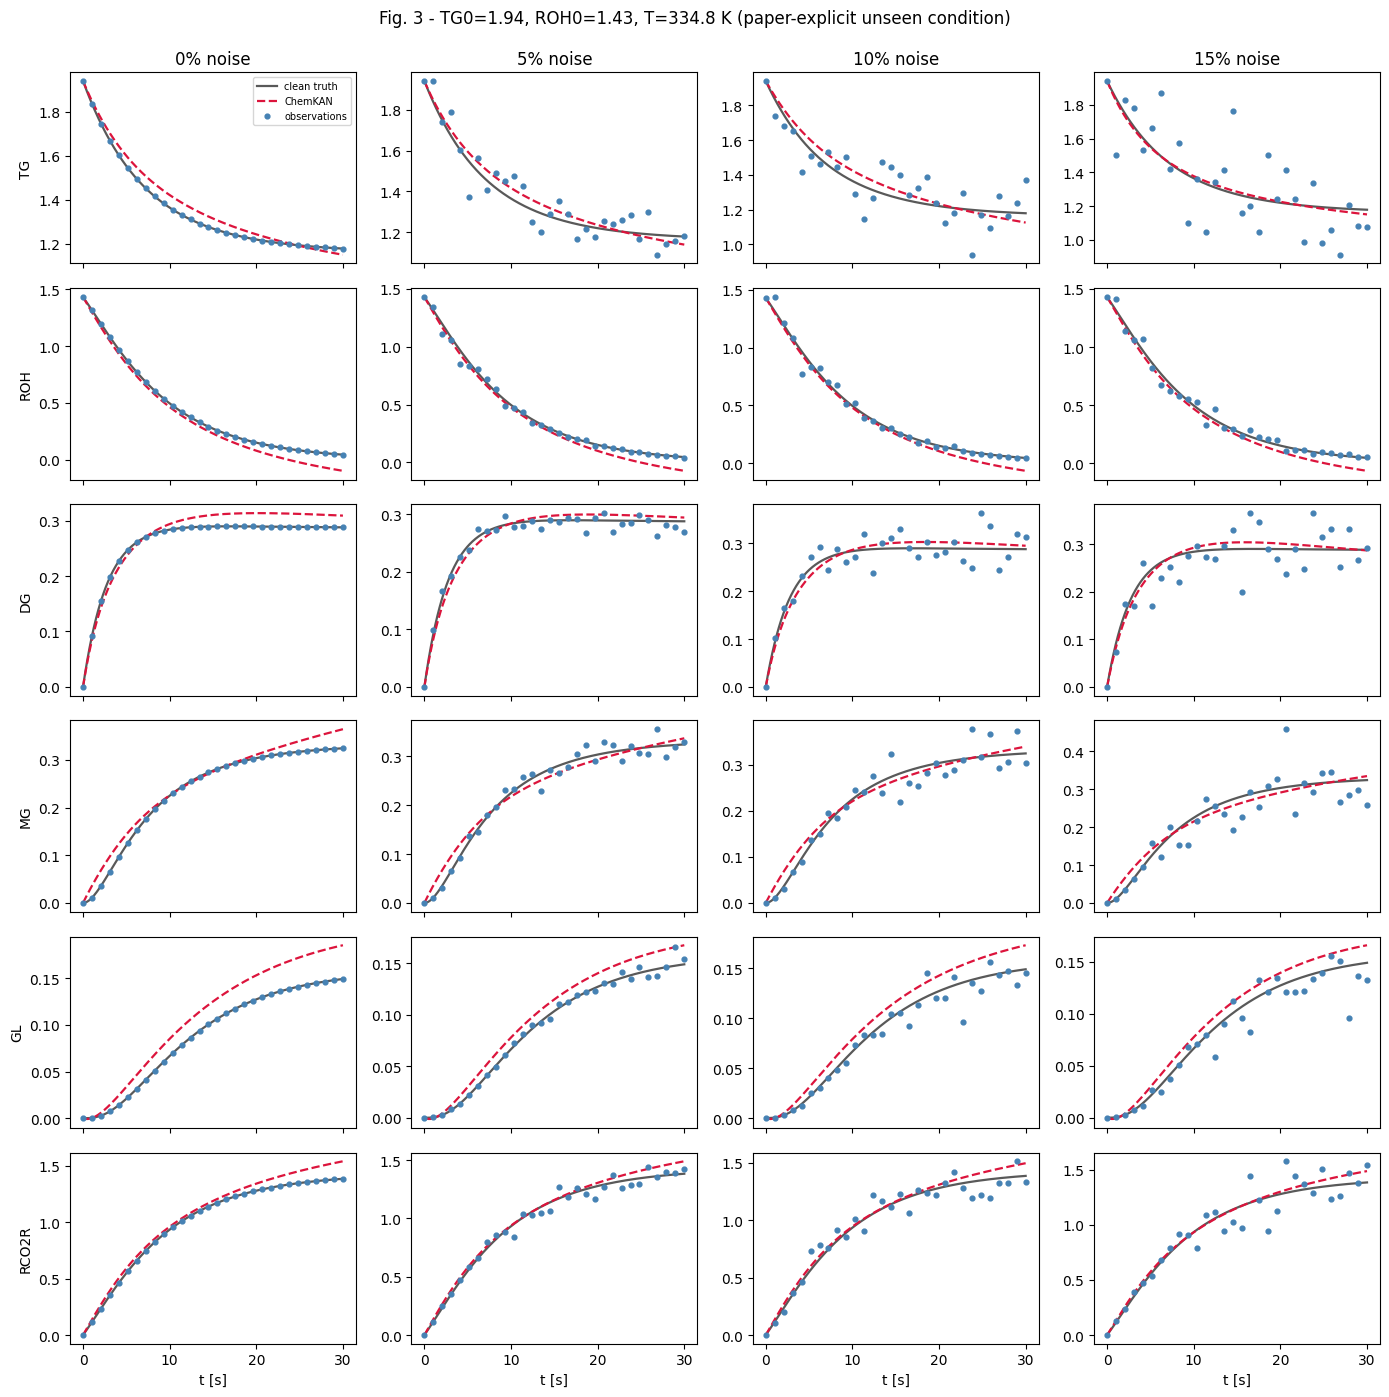

In [13]:
from evaluate_biodiesel import build_kinetic_core, solver_from_ckpt, integrate_biodiesel
from _data import load_input_scaling

art = np.load(ROOT / "chemkan/data/generated/biodiesel_fig3_condition.npz", allow_pickle=True)
td, tobs = art["t_dense"], art["t"]
truth_d, spec3 = art["states_dense"], [str(s) for s in art["species"]]
y0_3, T3 = art["y0"], float(art["T"])

fig, axes = plt.subplots(6, 4, figsize=(14, 14), sharex=True)
for c, pct in enumerate([0, 5, 10, 15]):
    ck = torch.load(chemkan_run(pct) / "checkpoint_final.pt", map_location="cpu", weights_only=False)
    core = build_kinetic_core(ck, len(spec3), "cpu")
    pred = integrate_biodiesel(core, load_input_scaling(ck, "cpu"), solver_from_ckpt(ck),
                               torch.as_tensor(y0_3, dtype=torch.float32).unsqueeze(0),
                               torch.tensor([T3]), torch.as_tensor(td, dtype=torch.float32),
                               "cpu")[:, 0, :].numpy()
    noisy = art[f"states_noise{pct:02d}"]
    for r, sp in enumerate(spec3):
        ax = axes[r, c]
        ax.plot(td, truth_d[:, r], color="0.35", lw=1.6, label="clean truth")
        ax.plot(td, pred[:, r], color="crimson", lw=1.6, ls="--", label="ChemKAN")
        ax.scatter(tobs, noisy[:, r], s=12, color="steelblue", zorder=3, label="observations")
        if c == 0: ax.set_ylabel(sp)
        if r == 0: ax.set_title(f"{pct}% noise")
        if r == 5: ax.set_xlabel("t [s]")
axes[0, 0].legend(fontsize=7)
fig.suptitle(f"Fig. 3 - TG0={y0_3[0]}, ROH0={y0_3[1]}, T={T3} K (paper-explicit unseen condition)", y=0.995)
fig.tight_layout()
if SAVE_FIGURES:
    for e in ("pdf", "png"):
        fig.savefig(FIGB / f"fig03_biodiesel_noise_columns.{e}", dpi=150, bbox_inches="tight")
plt.show()

**Reading Figure 3.** The reconstruction is qualitatively right at every noise level, and
visibly *not* exact even at 0 %: the 0 % prediction drives ROH negative at late times and
overshoots GL and R'CO2R. That is an unphysical excursion, not a plotting artifact — the
kinetic core is unconstrained in sign. The noisy-trained columns are not visibly worse than
the clean one, which is the paper's qualitative robustness claim.

### Figure 5A — noise robustness

Three metrics per model and noise level, all from the final checkpoint. The two test
metrics use the *same* predicted trajectories and differ only in their target: the noisy
observations (Eq. 18) versus the clean underlying trajectories (Eq. 22). At 0 % the two
coincide exactly.

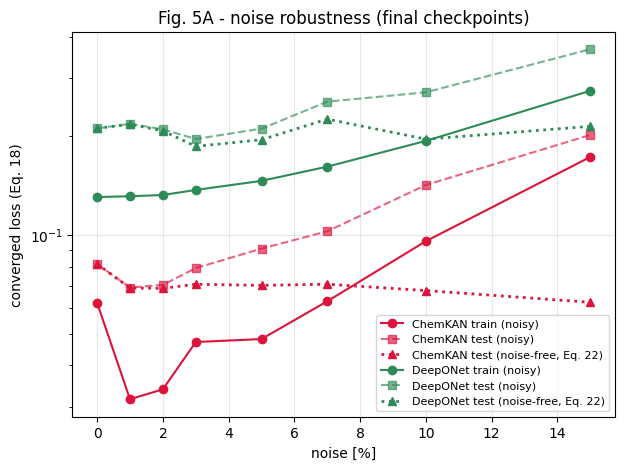

noise    CK train     CK test    CK clean    DO train     DO test    DO clean
   0%  6.2017e-02  8.1401e-02  8.1401e-02  1.3009e-01  2.1054e-01  2.1054e-01
   1%  3.1584e-02  6.9036e-02  6.8855e-02  1.3091e-01  2.1744e-01  2.1677e-01
   2%  3.3856e-02  7.0366e-02  6.8679e-02  1.3203e-01  2.0914e-01  2.0695e-01
   3%  4.7151e-02  7.9131e-02  7.0651e-02  1.3678e-01  1.9547e-01  1.8560e-01
   5%  4.8137e-02  9.0692e-02  7.0104e-02  1.4578e-01  2.1012e-01  1.9446e-01
   7%  6.2722e-02  1.0241e-01  7.0680e-02  1.6103e-01  2.5385e-01  2.2464e-01
  10%  9.5558e-02  1.4161e-01  6.7605e-02  1.9287e-01  2.7109e-01  1.9522e-01
  15%  1.7237e-01  2.0109e-01  6.2277e-02  2.7398e-01  3.6654e-01  2.1358e-01


In [14]:
def series(model, key):
    rows = [r for r in metrics if r["role"] == "plotted" and r["model"] == model]
    return [float(next(r for r in rows if int(r["noise_percent"]) == p)[key]) for p in levels]

fig, ax = plt.subplots(figsize=(7, 5))
for mo, col in (("ChemKAN", "crimson"), ("DeepONet", "seagreen")):
    ax.plot(levels, series(mo, "train_mse_noisy"), "o-", color=col, label=f"{mo} train (noisy)")
    ax.plot(levels, series(mo, "test_mse_noisy"), "s--", color=col, alpha=.65, label=f"{mo} test (noisy)")
    ax.plot(levels, series(mo, "test_mse_clean"), "^:", color=col, lw=2, label=f"{mo} test (noise-free, Eq. 22)")
ax.set_xlabel("noise [%]"); ax.set_ylabel("converged loss (Eq. 18)"); ax.set_yscale("log")
ax.set_title("Fig. 5A - noise robustness (final checkpoints)"); ax.legend(fontsize=8); ax.grid(alpha=.3)
if SAVE_FIGURES:
    for e in ("pdf", "png"):
        fig.savefig(FIGB / f"fig05a_biodiesel_noise_robustness.{e}", dpi=150, bbox_inches="tight")
plt.show()

print(f"{'noise':>5} {'CK train':>11} {'CK test':>11} {'CK clean':>11} "
      f"{'DO train':>11} {'DO test':>11} {'DO clean':>11}")
for i, p in enumerate(levels):
    print(f"{p:4d}% " + " ".join(f"{series(m, k)[i]:11.4e}" for m in ("ChemKAN", "DeepONet")
                                  for k in ("train_mse_noisy", "test_mse_noisy", "test_mse_clean")))

### Figure 5B — loss dynamics

Per-epoch noisy training MSE and noise-free test MSE, recorded every epoch by an
evaluation-only callback that runs under `no_grad`, takes no optimizer step, writes no
parameter and saves/restores the RNG state. It is evaluated *inside* the loss function, so
each logged test value belongs to exactly the parameter state that produced that epoch's
training loss. Training losses are bitwise identical with and without it.

The **0 % panel comes entirely from the clean replay** — both curves, one parameter
trajectory. Raw per-epoch values are plotted faintly underneath a **display-only** moving
average; the smoothing is cosmetic and the raw values are what is stored.

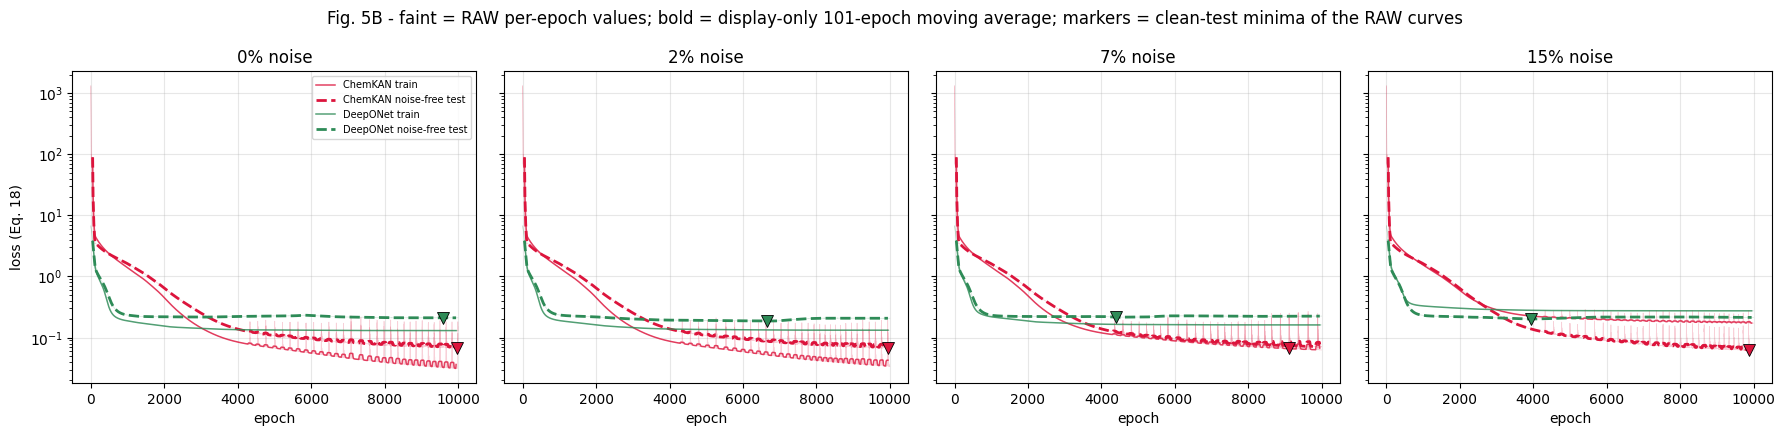

late-training oscillation span (last 20% of epochs, RAW):
noise model       train span  clean-test span
   0% ChemKAN         0.1188           0.1273
   0% DeepONet        0.0004           0.0022
   2% ChemKAN         0.1066           0.1274
   2% DeepONet        0.0003           0.0029
   7% ChemKAN         0.1894           0.2000
   7% DeepONet        0.0004           0.0029
  15% ChemKAN         0.1045           0.1164
  15% DeepONet        0.0004           0.0040


In [15]:
K = 101
smooth = lambda y: np.convolve(y, np.ones(K) / K, mode="valid")
off = (K - 1) // 2

fig, axes = plt.subplots(1, 4, figsize=(18, 4.4), sharey=True)
osc = {}
for ax, pct in zip(axes, (0, 2, 7, 15)):
    # 0 %: the replay, which reproduces B0 bitwise and adds the missing test columns.
    ck_dir = CKB / "noise/clean_replay_seed0" if pct == 0 else CKB / f"noise/noise{pct:02d}_seed0"
    for name, d, col in (("ChemKAN", ck_dir, "crimson"),
                         ("DeepONet", DON / f"noise{pct:02d}_seed0", "seagreen")):
        e, tr, te = history(d)
        late = e >= 0.8 * e.max()
        osc[(name, pct)] = (tr[late].max() - tr[late].min(), te[late].max() - te[late].min())
        ax.plot(e, tr, color=col, lw=.5, alpha=.20)              # RAW
        ax.plot(e, te, color=col, lw=.5, alpha=.20)              # RAW
        ax.plot(e[off:len(e) - off], smooth(tr), color=col, lw=1.1, alpha=.8, label=f"{name} train")
        ax.plot(e[off:len(e) - off], smooth(te), color=col, lw=2.0, ls="--",
                label=f"{name} noise-free test")
        i = int(np.argmin(te))
        ax.plot(e[i], te[i], "v", color=col, ms=9, mec="k", mew=.6)
    ax.set_yscale("log"); ax.set_xlabel("epoch"); ax.set_title(f"{pct}% noise"); ax.grid(alpha=.3)
axes[0].set_ylabel("loss (Eq. 18)"); axes[0].legend(fontsize=7, loc="upper right")
fig.suptitle(f"Fig. 5B - faint = RAW per-epoch values; bold = display-only {K}-epoch moving "
             "average; markers = clean-test minima of the RAW curves")
fig.tight_layout()
if SAVE_FIGURES:
    for e_ in ("pdf", "png"):
        fig.savefig(FIGB / f"fig05b_biodiesel_loss_dynamics.{e_}", dpi=150, bbox_inches="tight")
plt.show()

print("late-training oscillation span (last 20% of epochs, RAW):")
print(f"{'noise':>5} {'model':9s} {'train span':>12s} {'clean-test span':>16s}")
for (n, pc), (a, b) in sorted(osc.items(), key=lambda kv: (kv[0][1], kv[0][0])):
    print(f"{pc:4d}% {n:9s} {a:12.4f} {b:16.4f}")

**Overfitting is judged from both curves, not from the minimum alone.** A late clean-test
minimum by itself proves nothing: it can equally reflect noise on a flat curve. The
signature looked for is the clean-test error *rising* while the training loss is *still
falling*.

**The criterion and its thresholds are our diagnostic choice, not the paper's.** We
require: clean-test rise > 10 % above its minimum, *and* a further > 5 % fall in the
201-epoch smoothed training loss after that minimum, *and* the minimum before 90 % of the
epoch budget. The 10 % / 5 % thresholds, the 201-epoch smoothing window and the 90 % cutoff
were all picked by us; the paper states no quantitative criterion. Under this criterion,
**no run meets it** — at any noise level, for either model. A different threshold or window
could classify some runs differently, so the statement is "does not meet our criterion",
not "provably does not overfit". The measured quantities behind the verdict (clean-test
rise 0.3-11 %, post-minimum training-loss fall 0-3.6 %) are stored in
`biodiesel_fig5b_overfit_assessment.json` so the criterion can be re-applied at other
thresholds.

**Late-training oscillation bounds what the fixed-checkpoint comparison can resolve.**
Over the last 20 % of epochs the ChemKAN training loss swings by 0.10-0.19, while the
DeepONet's swings by 0.0003-0.0004 — three orders of magnitude smaller. The paper's
reported 0->1 % and 0->5 % training-loss increments (3.78e-5 and 9.64e-4) are three to four
orders of magnitude *below* the ChemKAN swing, so which side of its own oscillation a run's
10,000th epoch lands on dominates the comparison. That is why our measured increments come
out negative (see the comparison table below): the sign is governed by the oscillation, not
by the noise level. Resolving the claim would need epoch-averaged or multi-seed endpoints,
which are not run here.

**The cause of the oscillation is NOT established.** What is measured is that it appears in
the ChemKAN runs and not in the DeepONet runs at this budget. The two models differ in many
ways at once — ODE integration versus a direct map, KAN edge functions versus MLP layers,
learning rate 2e-3 versus 1e-3, 10,000 versus 10,000 epochs of very different cost — so
attributing it to the ODE solver, to the architecture, or to the optimizer setting would go
beyond the evidence. Candidate tests (a learning-rate sweep, a fixed-step solver, a
tighter-tolerance solve) have not been run.

### Figure 6 — 15 % noise profiles

No new training: the Fig.-5 15 % ChemKAN and DeepONet checkpoints, on one **training**
trajectory. The paper does not identify which case it plots, so case index 0 was fixed in
advance of looking at any prediction — a REPRODUCTION PLOTTING CHOICE.

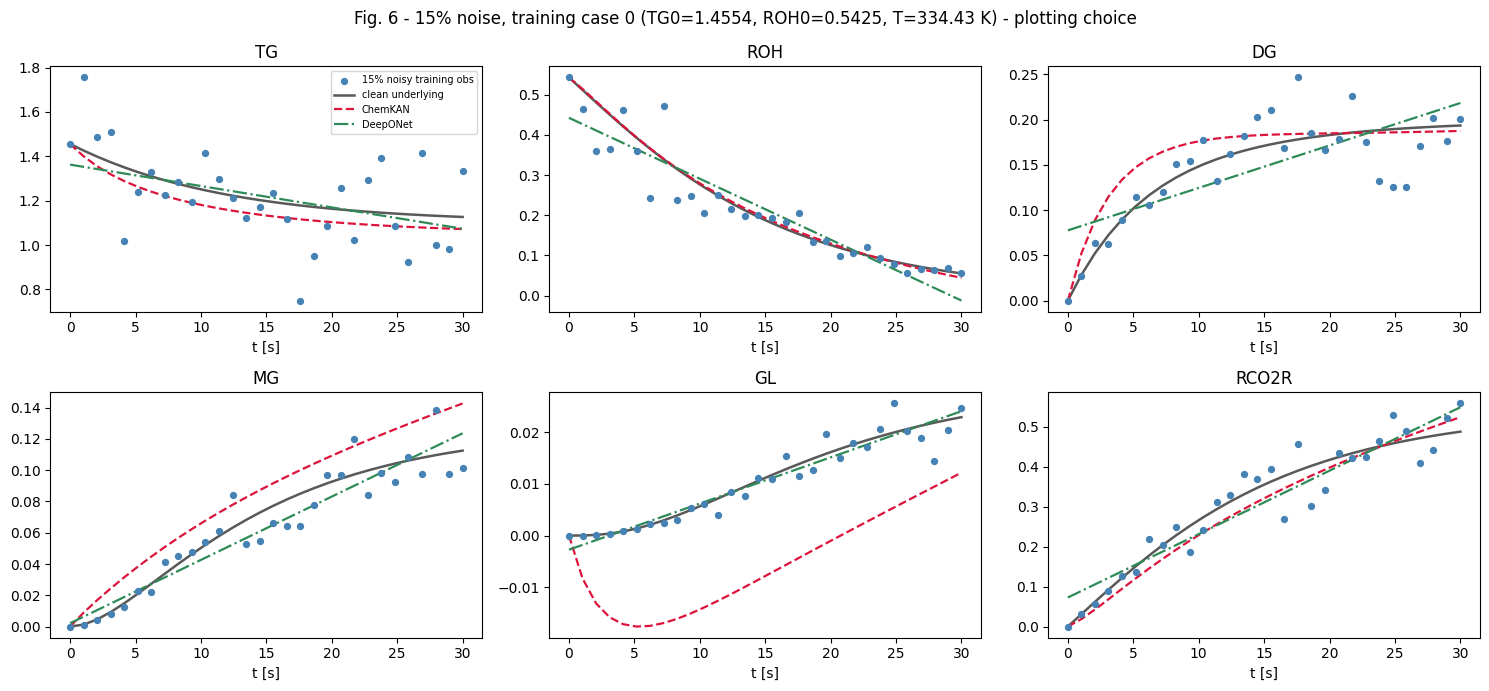

case 0: TG0=1.4554 ROH0=0.5425 T=334.43 K; all other species start at 0


In [16]:
import biodiesel_deeponet as bdon
from evaluate_biodiesel_deeponet import build_model
from chemkan.normalization import MinMaxNormalizer
from _data import load_biodiesel

CASE = 0                                  # REPRODUCTION PLOTTING CHOICE, fixed in advance
tr15 = load_biodiesel("train", noise_percent=15)
t6, spec6 = tr15["t"].numpy(), tr15["species"]
truth6 = tr15["species_TBm"][:, CASE, :].numpy()
noisy6 = tr15["targets_TBm"][:, CASE, :].numpy()
y06, T6 = tr15["Y0"][CASE], tr15["T_const"][CASE]

ck = torch.load(CKB / "noise/noise15_seed0/checkpoint_final.pt", map_location="cpu", weights_only=False)
core = build_kinetic_core(ck, len(spec6), "cpu")
pred_ck = integrate_biodiesel(core, load_input_scaling(ck, "cpu"), solver_from_ckpt(ck),
                              y06.unsqueeze(0), T6.reshape(1), tr15["t"], "cpu")[:, 0, :].numpy()

dck = torch.load(DON / "noise15_seed0/checkpoint_final.pt", map_location="cpu", weights_only=False)
dmod = build_model(dck, "cpu"); nrm = dck["normalization"]
full_n = MinMaxNormalizer(nrm["u_min"], nrm["u_max"]); loss_n = full_n.subset(slice(0, len(spec6)))
b6, tau6 = bdon.prepare_inputs({"Y0": y06.unsqueeze(0), "T_const": T6.reshape(1), "t": tr15["t"]},
                               full_n, float(nrm["t_end_s"]))
with torch.no_grad():
    pred_do = loss_n.denormalize(dmod(b6, tau6))[:, 0, :].numpy()   # inverse-transform for physical plot

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for k, sp in enumerate(spec6):
    ax = axes[k // 3, k % 3]
    ax.scatter(t6, noisy6[:, k], s=18, color="steelblue", zorder=3, label="15% noisy training obs")
    ax.plot(t6, truth6[:, k], color="0.35", lw=1.8, label="clean underlying")
    ax.plot(t6, pred_ck[:, k], color="crimson", lw=1.6, ls="--", label="ChemKAN")
    ax.plot(t6, pred_do[:, k], color="seagreen", lw=1.6, ls="-.", label="DeepONet")
    ax.set_title(sp); ax.set_xlabel("t [s]")
axes[0, 0].legend(fontsize=7)
fig.suptitle(f"Fig. 6 - 15% noise, training case {CASE} (TG0={float(y06[0]):.4f}, "
             f"ROH0={float(y06[1]):.4f}, T={float(T6):.2f} K) - plotting choice")
fig.tight_layout()
if SAVE_FIGURES:
    for e_ in ("pdf", "png"):
        fig.savefig(FIGB / f"fig06_biodiesel_15pct_profiles.{e_}", dpi=150, bbox_inches="tight")
plt.show()
print(f"case {CASE}: TG0={float(y06[0]):.4f} ROH0={float(y06[1]):.4f} T={float(T6):.2f} K; "
      f"all other species start at 0")

### Comparison against the paper's reported findings

`paper result | our result | status | remaining difference | artifact path`, from the
single authoritative table `results/reproduction/tables/reproduction_comparison.csv`, which
covers Figures 3-8 and Table I. The biodiesel rows are shown here; the hydrogen rows are in
Notebook 08.

**"evaluation completed" is not "paper result matched".** Every row below was evaluated
end to end from committed artifacts; the `status` column states separately whether the
paper's reported result was reproduced.

In [17]:
comp = [r for r in csv.DictReader(open(TAB / "reproduction_comparison.csv"))
        if r["figure"] in ("Fig. 3", "Fig. 4", "Fig. 5A", "Fig. 5B", "Fig. 6")]
for r in comp:
    print(f"[{r['figure']:8s}] {r['status'].upper()}")
    print(f"    paper: {r['paper_result']} = {r['paper_value']}")
    print(f"    ours : {r['our_result']}")
    print(f"    -> {r['remaining_difference']}")
    print(f"    artifact: {r['artifact_path']}\n")

[Fig. 3  ] EVALUATION COMPLETED; QUALITATIVELY SIMILAR, NOT QUANTITATIVELY MATCHED
    paper: Smooth reconstruction of the explicit unseen condition at 0/5/10/15% noise = qualitative
    ours : all four columns produced for TG0=1.94, ROH0=1.43, T=334.8 K; all six species
    -> Reconstruction is visibly imperfect even at 0%: ROH is driven negative at late times and GL / R'CO2R overshoot. The noisy columns are not visibly worse than the clean one.
    artifact: results/reproduction/figures/biodiesel/fig03_biodiesel_noise_columns.pdf

[Fig. 4  ] EVALUATION COMPLETED; NOT MATCHED
    paper: ChemKAN training scaling slope = -1.0
    ours : -0.41 (R2 0.19, SE 0.49)
    -> Descriptive all-point regression; the paper regresses a pre-saturation subset, so the fitting scope differs. Our curve is non-monotonic and the fit is poorly determined.
    artifact: results/reproduction/tables/biodiesel_fig4_fits.csv

[Fig. 4  ] EVALUATION COMPLETED; NOT MATCHED
    paper: ChemKAN testing scaling slope =

---

## Figure 4 — neural scaling

Widths were fixed by **digitizing the paper's own figure** rather than guessed
(`docs/fig4_width_matrix.md`, `chemkan/scripts/diagnostics/digitize_paper_fig4.py`). ChemKAN
h = 2, 3, 4, 10, 17 → 78, 117, 156, 390, 663 measured parameters at 5,000 epochs;
DeepONet w = 3, 5, 6, 8, 10, 13 → 85, 169, 220, 340, 484, 745 at 50,000 epochs. These
**reconstruct the plotted parameter range; they are not exact paper-specified
architectures.** The paper's ≈650-parameter ChemKAN marker matches no `39h` width and is
preserved as an unexplained discrepancy — h=17 (663) is merely the nearest feasible one.

**h = 4 is reused, not retrained**: it is the clean replay's `checkpoint_epoch_5000.pt`,
the model after exactly 5,000 optimizer steps under every Fig.-4 setting.

In [18]:
import subprocess
FIT = TAB / "biodiesel_fig4_fits.csv"
PTS = TAB / "biodiesel_fig4_points.csv"
pts4 = list(csv.DictReader(open(PTS))); fits4 = list(csv.DictReader(open(FIT)))

print(f"{'model':9s} {'w':>3s} {'params':>7s} {'train(final)':>13s} {'test(final)':>12s} "
      f"{'train late median':>18s} {'late band':>24s}")
for r in sorted(pts4, key=lambda r: (r["model"], int(r["parameters"]))):
    band = f"[{float(r['train_late_min']):.2e},{float(r['train_late_max']):.2e}]"
    print(f"{r['model']:9s} {int(r['width']):3d} {int(r['parameters']):7d} "
          f"{float(r['train_loss']):13.4e} {float(r['test_loss']):12.4e} "
          f"{float(r['train_loss_late_median']):18.4e} {band:>24s}"
          f"{'  REUSED' if r['reused'] == 'True' else ''}")
print()
for f_ in fits4:
    print(f"{f_['model']:9s} {f_['metric']:23s} slope {float(f_['slope']):+.3f}  "
          f"R2 {float(f_['r_squared']):.3f}  SE {float(f_['std_error']):.3f}  "
          f"n={f_['n_included']}  excluded [{f_['excluded']}]")
print(f"\nmask: {fits4[0]['mask_rule']}")

model       w  params  train(final)  test(final)  train late median                late band
ChemKAN     2      78    3.6699e-01   4.6151e-01         3.9819e-01      [3.67e-01,4.43e-01]
ChemKAN     3     117    4.6852e-02   7.1882e-02         5.4084e-02      [4.69e-02,6.32e-02]
ChemKAN     4     156    6.8374e-02   1.1164e-01         7.5263e-02      [6.75e-02,1.55e-01]  REUSED
ChemKAN    10     390    5.2373e-02   6.4873e-02         4.2398e-02      [3.41e-02,2.13e-01]
ChemKAN    17     663    8.9945e-02   1.4363e-01         1.1085e-01      [8.92e-02,1.40e-01]
DeepONet    3      85    2.1641e-01   3.5942e-01         2.1648e-01      [2.16e-01,2.17e-01]
DeepONet    5     169    1.5115e-01   2.5387e-01         1.5117e-01      [1.51e-01,1.53e-01]
DeepONet    6     220    5.6484e-01   6.7142e-01         5.6484e-01      [5.65e-01,5.65e-01]
DeepONet    8     340    1.2943e-01   2.2386e-01         1.2945e-01      [1.29e-01,1.30e-01]
DeepONet   10     484    1.3082e-01   2.5745e-01         1.308

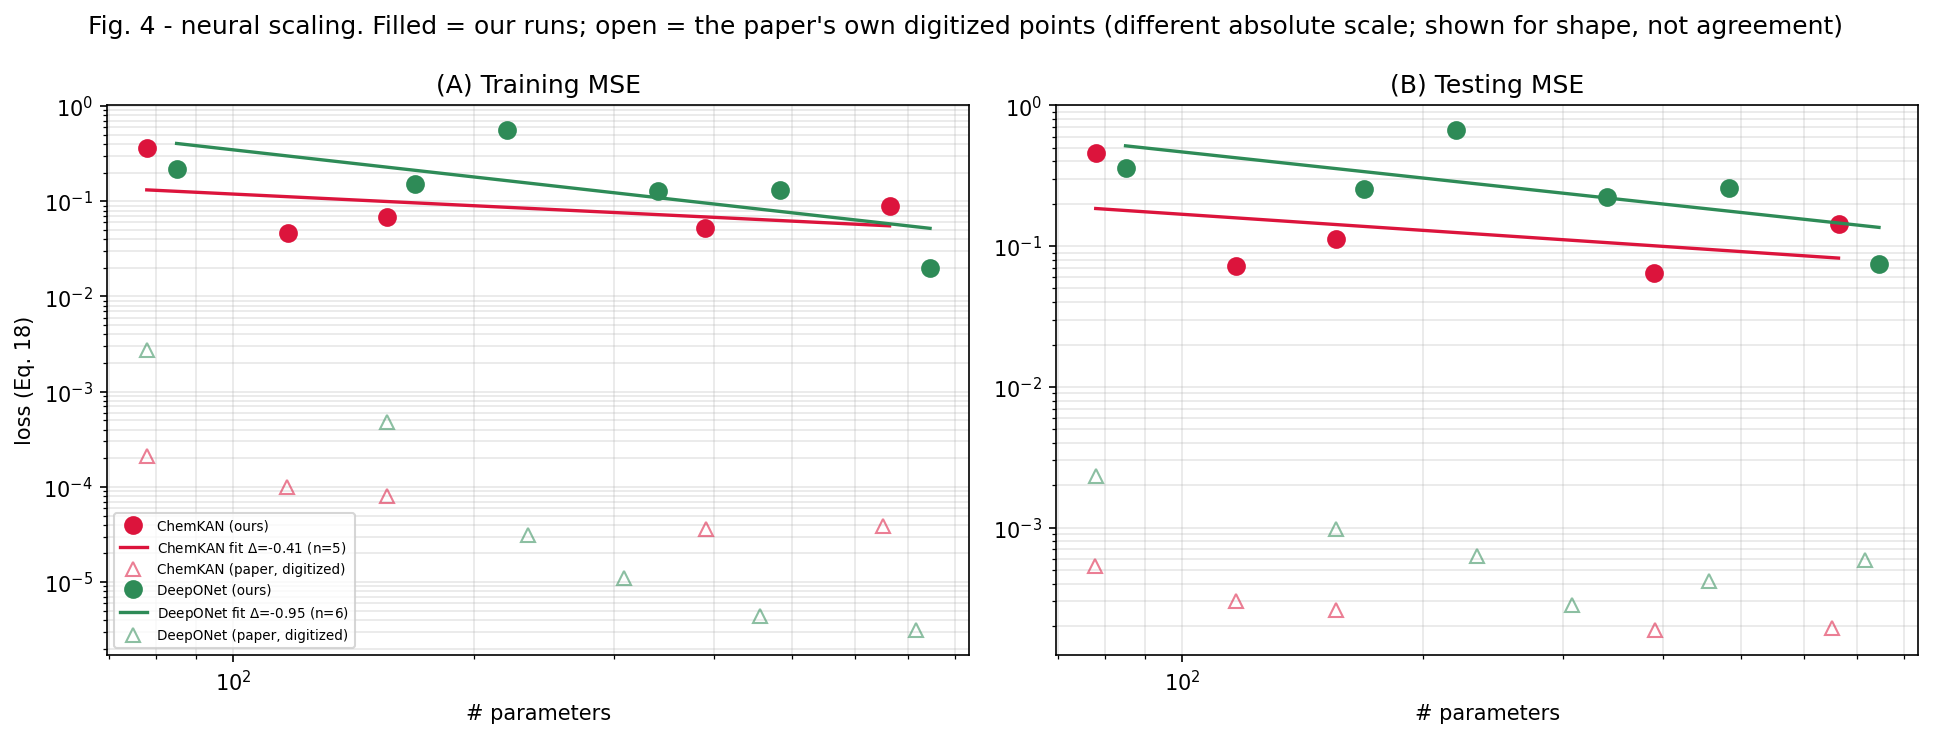

In [19]:
from IPython.display import Image, display
display(Image(filename=str(FIGB / "fig04_biodiesel_neural_scaling.png")))

### Reading Figure 4 — our scaling measurement does not reproduce the paper's slopes

| series | paper | ours | R² | SE |
|---|---|---|---|---|
| ChemKAN training | −1.0 | **−0.41** | 0.19 | 0.49 |
| ChemKAN testing | −0.6 | **−0.38** | 0.18 | 0.47 |
| DeepONet training | −4.0 | **−0.95** | 0.46 | 0.52 |
| DeepONet testing | −1.4 | **−0.62** | 0.45 | 0.34 |

**These are descriptive regressions, not scaling-law estimates.** Each is an ordinary
least-squares line through *all* of our points, reported to summarise the data actually
obtained — not to assert a scaling exponent. Every standard error is comparable to the
slope itself and no R² exceeds 0.46, so the lines carry little predictive weight; and the
**fitting scope differs from the paper's**, which regresses only a pre-saturation subset.
A slope fitted over all points and a slope fitted over a pre-saturation subset are not the
same quantity, so the ours-vs-paper column above compares numbers obtained under different
procedures and should be read as such. Two concrete obstacles, both measured rather than
assumed:

1. **ChemKAN's fixed-checkpoint values are draws from an oscillating band.** Over the last
   20 % of each run the raw training loss spans e.g. `[3.41e-2, 2.13e-1]` at h=10 against a
   final value of `5.24e-2` — the band is *wider than the value*. The curve is therefore
   non-monotonic in parameter count: h=3 (117 params) ends below h=4, h=10 and h=17. A
   robust late-epoch median instead of the final checkpoint barely moves the slope
   (−0.43 vs −0.41), so the oscillation alone does not explain the weak trend; it does
   explain why individual points are unreliable.
2. **The DeepONet w=6 point (220 params) sits far off the trend**, at 5.65e-1 — worse than
   w=3. Its loss has **plateaued at a high value**: over the last 20 % of its 50,000 epochs
   the training loss spans `[5.65e-1, 5.65e-1]`, so the point is not noisy. A flat history
   at a high value is all that is measured; it does **not** by itself establish *why* — a
   poor basin, saturated ReLUs, and a learning rate ill-suited to that width would all look
   like this, and none has been tested. The point is **kept**: dropping or re-tuning it
   after seeing that it hurts the fit is exactly the post-hoc selection this reproduction
   avoids.

**Fit mask.** All points are included for every series, for every metric. The paper fits
"prior to saturation"; our curves offer no identifiable saturation regime to cut at,
because they are non-monotonic in parameter count. A minimum-based mask was tried first and
rejected: it degenerated to two points for the ChemKAN training series, giving a trivially
perfect R² and an undefined standard error. Keeping all points and reporting the poor fit
quality is the honest option, but it does mean our fitting scope is **not** the paper's.

**On the digitized paper points** shown as open markers: they come from the paper's own
figure and sit on a different absolute scale from our losses (the documented absolute-MSE
gap). They are plotted for shape only. The earlier check that refitting them recovers
−1.0/−0.6/−4.0/−1.4 validated **the digitization**, not any model trained here.